**Capítulo 3 - Classificação**

*Este notebook apresenta o fluxo essencial de problemas de classificação: preparar dados, treinar classificadores, avaliar desempenho com métricas apropriadas e lidar com cenários binários, multiclasse, multirrótulo e multioutput.*

*Este notebook contém a tradução e adaptação das células de exemplo do Capítulo 3. A seção final de soluções dos exercícios foi deixada fora do notebook principal e ficará organizada em `Respostas.md`.*

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/03_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir no Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Configuração

*Antes de iniciar, conferimos as versões principais e ajustamos a aparência dos gráficos. Isso deixa o notebook mais reprodutível e evita problemas quando ele é executado em outro ambiente.*

*Este projeto requer Python 3.7 ou superior.*

In [1]:
import sys

assert sys.version_info >= (3, 7)

*Ele também requer Scikit-Learn >= 1.0.1.*

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

*Como no capítulo anterior, definimos tamanhos padrão de fonte para deixar as figuras mais legíveis.*

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

*Também criamos a pasta `images/classification`, caso ainda não exista, e definimos `save_fig()`, usada ao longo do notebook para salvar figuras em alta resolução.*

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# MNIST

*O MNIST é um conjunto clássico de imagens de dígitos manuscritos. Cada imagem tem 28 x 28 pixels, achatados em 784 atributos, e o alvo indica qual dígito aparece na imagem. Ele é pequeno o suficiente para estudo, mas realista o bastante para mostrar vários desafios de classificação.*

In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [6]:
# código extra – a descrição é um pouco longa
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [7]:
mnist.keys()  # código extra – usamos apenas data e target neste notebook

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [8]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [9]:
X.shape

(70000, 784)

In [10]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [11]:
y.shape

(70000,)

In [12]:
28 * 28

784

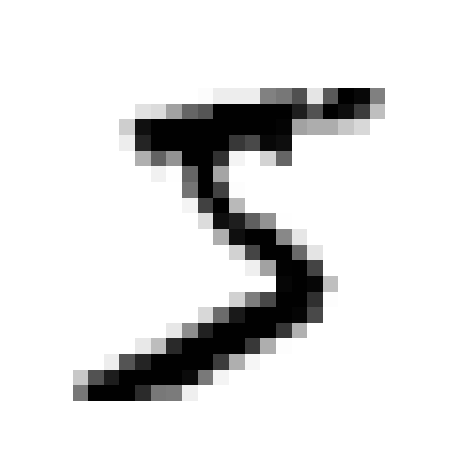

In [13]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
save_fig("some_digit_plot")  # código extra
plt.show()

In [14]:
y[0]

'5'

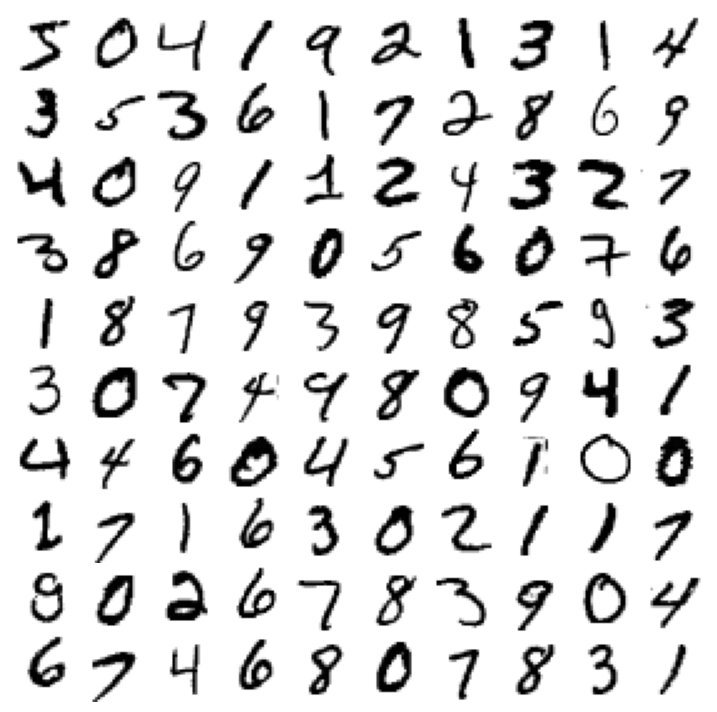

In [15]:
# código extra – esta célula gera e salva a Figura 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
save_fig("more_digits_plot", tight_layout=False)
plt.show()

In [16]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Treinando um Classificador Binário

*Começamos transformando o problema em uma pergunta simples: esta imagem é o dígito 5 ou não? Esse formato binário facilita entender as métricas antes de avançar para classificação multiclasse.*

In [17]:
y_train_5 = (y_train == '5')  # True para todos os 5, False para os demais dígitos
y_test_5 = (y_test == '5')

In [18]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [19]:
sgd_clf.predict([some_digit])

array([ True])

# Medidas de Desempenho

*Em classificação, acurácia nem sempre conta a história inteira. Vamos avaliar o classificador com validação cruzada, matriz de confusão, precisão, revocação, F1, curvas precisão-revocação e ROC.*

## Medindo Acurácia com Validação Cruzada

*A validação cruzada estima o desempenho dividindo o conjunto de treino em partes. Ainda assim, em problemas desbalanceados, uma acurácia alta pode ser enganosa se o modelo simplesmente favorecer a classe majoritária.*

In [20]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # adicione shuffle=True se o conjunto de dados não
                                       # já estiver embaralhado
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [22]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [23]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

## Matriz de Confusão

*A matriz de confusão mostra quantos exemplos caíram em cada combinação de classe real e classe prevista. Ela separa acertos e erros em verdadeiros positivos, falsos positivos, verdadeiros negativos e falsos negativos.*

In [24]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [26]:
y_train_perfect_predictions = y_train_5  # fingimos que alcançamos a perfeição
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

## Precisão e Revocação

*Precisão responde: entre os exemplos previstos como positivos, quantos realmente eram positivos? Revocação responde: entre todos os positivos reais, quantos o modelo conseguiu encontrar? O equilíbrio entre as duas depende do objetivo do problema.*

In [27]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)  # == 3530 / (687 + 3530)

np.float64(0.8370879772350012)

In [28]:
# código extra – esta célula também calcula a precisão: VP / (FP + VP)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

np.float64(0.8370879772350012)

In [29]:
recall_score(y_train_5, y_train_pred)  # == 3530 / (1891 + 3530)

np.float64(0.6511713705958311)

In [30]:
# código extra – esta célula também calcula a revocação: VP / (FN + VP)
cm[1, 1] / (cm[1, 0] + cm[1, 1])

np.float64(0.6511713705958311)

In [31]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

np.float64(0.7325171197343847)

In [32]:
# código extra – esta célula também calcula o escore F1
cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)

np.float64(0.7325171197343847)

## Relação de Compromisso entre Precisão e Revocação

*Muitos classificadores calculam uma pontuação interna e depois aplicam um limiar para decidir a classe. Ao aumentar esse limiar, normalmente ganhamos precisão e perdemos revocação; ao reduzir, acontece o oposto.*

In [33]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [34]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [35]:
y_some_digit_pred

array([ True])

In [36]:
# código extra – mostra que y_scores > 0 produz o mesmo resultado que
#              chamar predict()
y_scores > 0

array([ True])

In [37]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [38]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

In [39]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

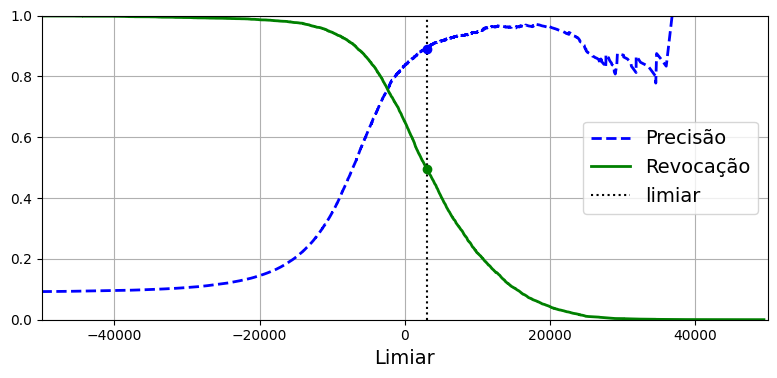

In [40]:
plt.figure(figsize=(8, 4))  # código extra – não é necessário, apenas formatação
plt.plot(thresholds, precisions[:-1], "b--", label="Precisão", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Revocação", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="limiar")

# código extra – esta seção apenas melhora o gráfico e salva a Figura 3–5
idx = (thresholds >= threshold).argmax()  # primeiro índice >= limiar
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Limiar")
plt.legend(loc="center right")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

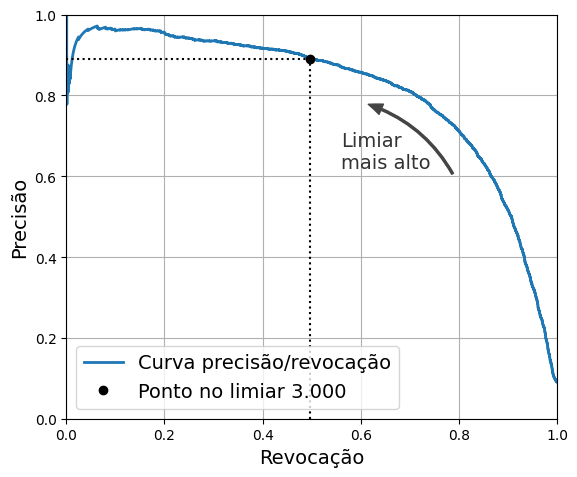

In [41]:
import matplotlib.patches as patches  # código extra – para a seta curva

plt.figure(figsize=(6, 5))  # código extra – não é necessário, apenas formatação

plt.plot(recalls, precisions, linewidth=2, label="Curva precisão/revocação")

# código extra – apenas melhora o gráfico e salva a Figura 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Ponto no limiar 3.000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Limiar\nmais alto", color="#333333")
plt.xlabel("Revocação")
plt.ylabel("Precisão")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()

In [42]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [43]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [44]:
precision_score(y_train_5, y_train_pred_90)

np.float64(0.9000345901072293)

In [45]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

np.float64(0.4799852425751706)

## Curva ROC

*A curva ROC compara a taxa de verdadeiros positivos com a taxa de falsos positivos para vários limiares. Ela ajuda a avaliar classificadores binários por outro ângulo, especialmente quando queremos comparar modelos diferentes.*

In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

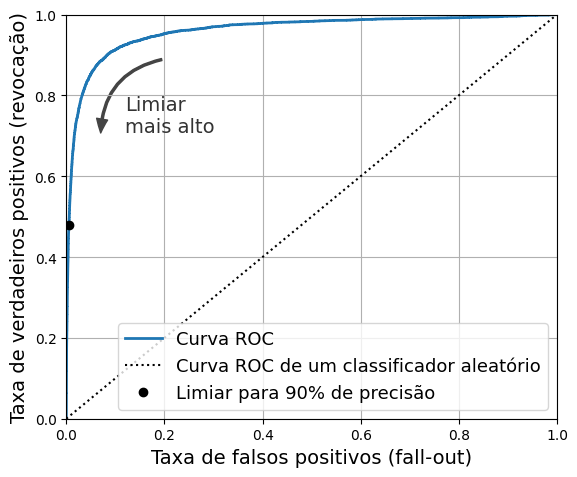

In [47]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # código extra – não é necessário, apenas formatação
plt.plot(fpr, tpr, linewidth=2, label="Curva ROC")
plt.plot([0, 1], [0, 1], 'k:', label="Curva ROC de um classificador aleatório")
plt.plot([fpr_90], [tpr_90], "ko", label="Limiar para 90% de precisão")

# código extra – apenas melhora o gráfico e salva a Figura 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Limiar\nmais alto", color="#333333")
plt.xlabel('Taxa de falsos positivos (fall-out)')
plt.ylabel('Taxa de verdadeiros positivos (revocação)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
save_fig("roc_curve_plot")

plt.show()

In [48]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

**Aviso:** a célula seguinte pode levar alguns minutos para executar.

In [49]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

In [50]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [51]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

*Essas são probabilidades estimadas. Entre as imagens que o modelo classificou como positivas com probabilidade entre 50% e 60%, cerca de 94% são realmente positivas.*

In [52]:
# Não está no código do livro
idx_50_to_60 = (y_probas_forest[:, 1] > 0.50) & (y_probas_forest[:, 1] < 0.60)
print(f"{(y_train_5[idx_50_to_60]).sum() / idx_50_to_60.sum():.1%}")

94.0%


In [53]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

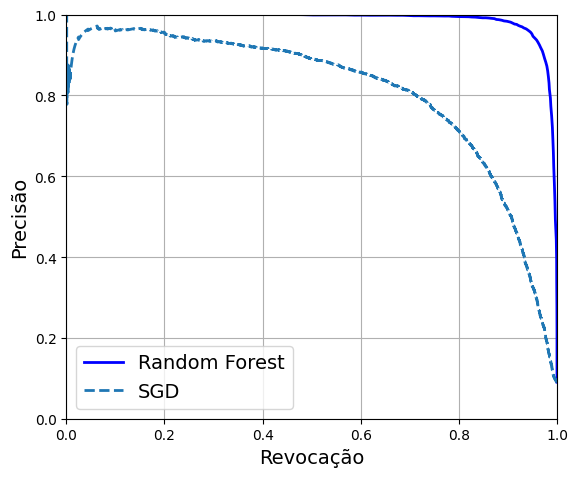

In [54]:
plt.figure(figsize=(6, 5))  # código extra – não é necessário, apenas formatação

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# código extra – apenas melhora o gráfico e salva a Figura 3–8
plt.xlabel("Revocação")
plt.ylabel("Precisão")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("pr_curve_comparison_plot")

plt.show()

*Poderíamos usar `cross_val_predict(forest_clf, X_train, y_train_5, cv=3)` para calcular `y_train_pred_forest`, mas como já temos as probabilidades estimadas, basta aplicar o limiar padrão de 50% para obter as mesmas previsões muito mais rapidamente.*

In [55]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # probabilidade positiva >= 50%
f1_score(y_train_5, y_train_pred_forest)

np.float64(0.9274509803921569)

In [56]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983436731328145)

In [57]:
precision_score(y_train_5, y_train_pred_forest)

np.float64(0.9897468089558485)

In [58]:
recall_score(y_train_5, y_train_pred_forest)

np.float64(0.8725327430363402)

# Classificação Multiclasse

*Agora voltamos ao problema original: distinguir entre os dez dígitos, de 0 a 9. Alguns algoritmos já lidam diretamente com múltiplas classes; outros combinam classificadores binários usando estratégias como um-contra-todos ou um-contra-um.*

*SVMs não escalam bem para conjuntos de dados grandes, então treinamos apenas nas primeiras 2.000 instâncias. Caso contrário, esta seção demoraria muito para executar.*

In [59]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])  # y_train, não y_train_5

SVC(random_state=42)

In [60]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [61]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [62]:
class_id = some_digit_scores.argmax()
class_id

np.int64(5)

In [63]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [64]:
svm_clf.classes_[class_id]

'5'

*Se quiser que `decision_function()` retorne todas as 45 pontuações, você pode definir o hiperparâmetro `decision_function_shape` como `"ovo"`. O valor padrão é `"ovr"`, mas isso não deve confundir: `SVC` sempre usa OvO no treinamento. Esse hiperparâmetro afeta apenas se as 45 pontuações são agregadas ou não.*

In [65]:
# código extra – mostra como obter todas as 45 pontuações OvO, se necessário
svm_clf.decision_function_shape = "ovo"
some_digit_scores_ovo = svm_clf.decision_function([some_digit])
some_digit_scores_ovo.round(2)

array([[ 0.11, -0.21, -0.97,  0.51, -1.01,  0.19,  0.09, -0.31, -0.04,
        -0.45, -1.28,  0.25, -1.01, -0.13, -0.32, -0.9 , -0.36, -0.93,
         0.79, -1.  ,  0.45,  0.24, -0.24,  0.25,  1.54, -0.77,  1.11,
         1.13,  1.04,  1.2 , -1.42, -0.53, -0.45, -0.99, -0.95,  1.21,
         1.  ,  1.  ,  1.08, -0.02, -0.67, -0.14, -0.3 , -0.13,  0.25]])

In [66]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [67]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [68]:
len(ovr_clf.estimators_)

10

In [69]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [70]:
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

**Aviso:** as duas células seguintes podem levar alguns minutos cada para executar.

In [71]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8983, 0.891 , 0.9018])

# Análise de Erros

*Depois de treinar um classificador multiclasse, não basta olhar apenas a acurácia. A matriz de confusão ajuda a descobrir quais dígitos são confundidos com mais frequência e onde vale a pena melhorar o pré-processamento ou o modelo.*

**Aviso:** a célula seguinte pode levar alguns minutos para executar.

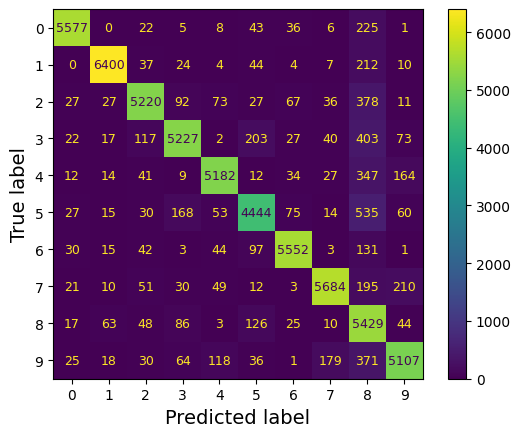

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
plt.rc('font', size=9)  # código extra – diminui o texto
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

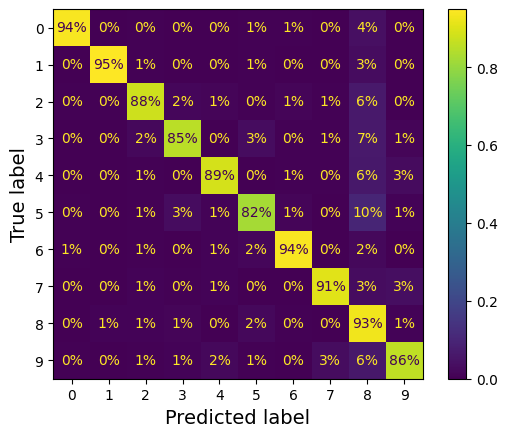

In [74]:
plt.rc('font', size=10)  # código extra
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

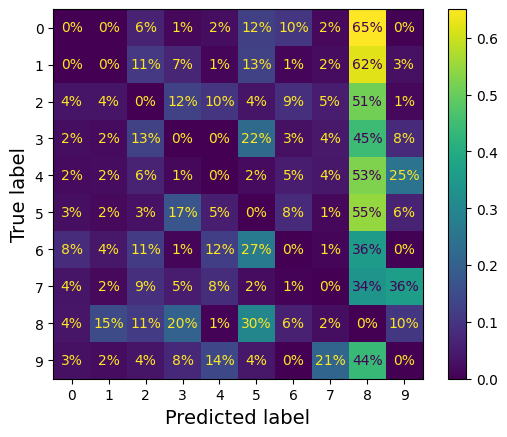

In [75]:
sample_weight = (y_train_pred != y_train)
plt.rc('font', size=10)  # código extra
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

*Vamos colocar todos os gráficos em algumas figuras, seguindo a organização visual usada no livro.*

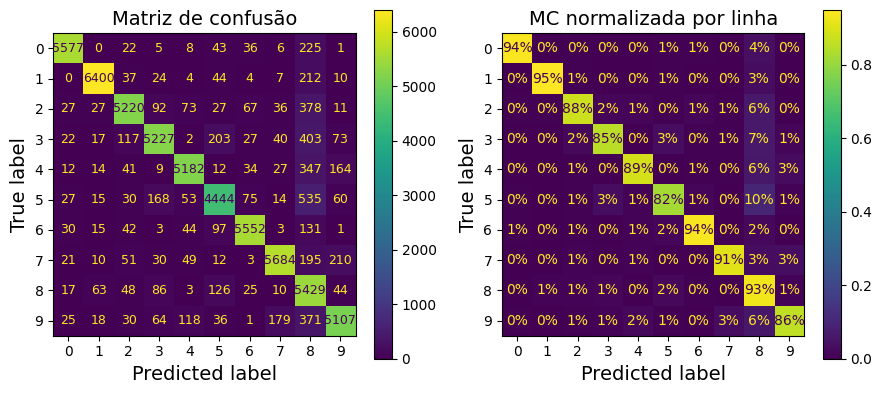

In [76]:
# código extra – esta célula gera e salva a Figura 3–9
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])
axs[0].set_title("Matriz de confusão")
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("MC normalizada por linha")
save_fig("confusion_matrix_plot_1")
plt.show()

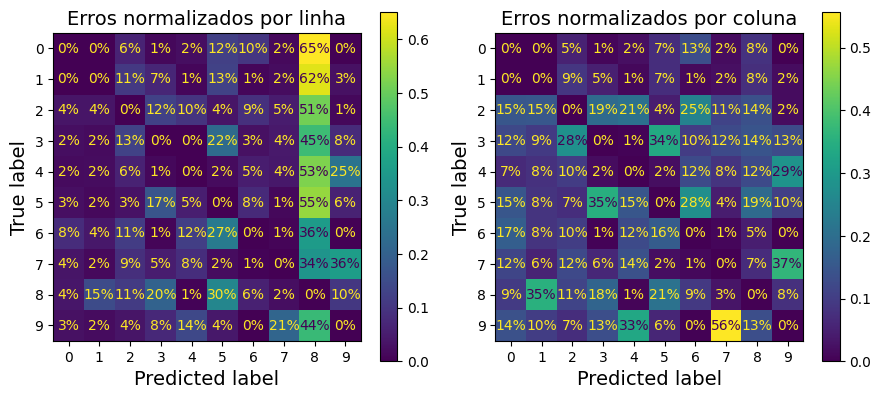

In [77]:
# código extra – esta célula gera e salva a Figura 3–10
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0],
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
axs[0].set_title("Erros normalizados por linha")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
axs[1].set_title("Erros normalizados por coluna")
save_fig("confusion_matrix_plot_2")
plt.show()
plt.rc('font', size=14)  # restaura o tamanho padrão das fontes

In [78]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

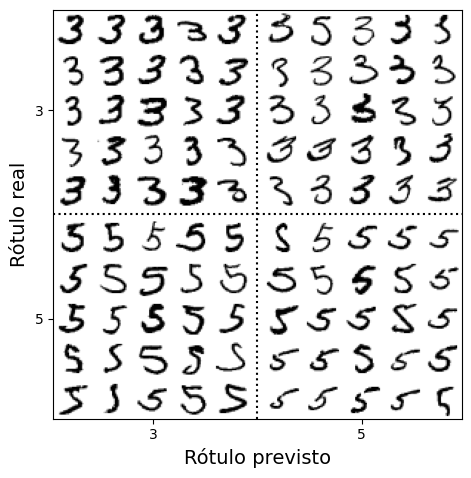

In [79]:
# código extra – esta célula gera e salva a Figura 3–11
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Rótulo previsto")
plt.ylabel("Rótulo real")
save_fig("error_analysis_digits_plot")
plt.show()

*Observação: há várias formas de codificar um gráfico como este, mas acertar os rótulos dos eixos pode ser trabalhoso. Algumas alternativas seriam usar [GridSpecs aninhados](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/gridspec_nested.html), juntar todos os dígitos de cada bloco em uma única imagem ou usar [subfigures](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subfigures.html), disponíveis desde o Matplotlib 3.4.*

# Classificação Multirrótulo

*Na classificação multirrótulo, cada instância pode ter mais de uma resposta correta ao mesmo tempo. Aqui, por exemplo, podemos prever se o dígito é grande e se é ímpar.*

In [80]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [81]:
knn_clf.predict([some_digit])

array([[False,  True]])

**Aviso:** a célula seguinte pode levar alguns minutos para executar.

In [82]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

np.float64(0.9764102655606048)

In [83]:
# código extra – mostra que o ganho é desprezível ao usar
#              average="weighted", pois as classes já estão bem equilibradas.
f1_score(y_multilabel, y_train_knn_pred, average="weighted")

np.float64(0.9778357403921755)

In [84]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

In [85]:
chain_clf.predict([some_digit])

array([[0., 1.]])

# Classificação com Múltiplas Saídas

*Na classificação com múltiplas saídas, cada instância também recebe várias respostas, mas cada saída pode ter múltiplas classes. O exemplo final trata remoção de ruído: para cada pixel da imagem, o modelo prevê o valor limpo correspondente.*

In [86]:
np.random.seed(42)  # para tornar este exemplo reprodutível
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

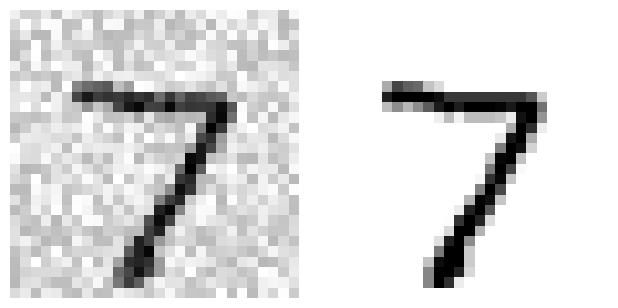

In [87]:
# código extra – esta célula gera e salva a Figura 3–12
plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])
save_fig("noisy_digit_example_plot")
plt.show()

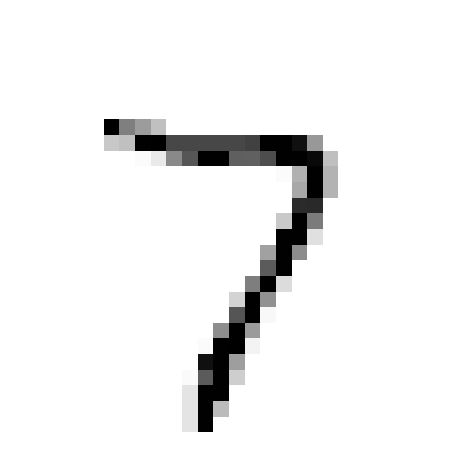

In [88]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
save_fig("cleaned_digit_example_plot")  # código extra – salva a Figura 3–13
plt.show()